In [3]:
!pip install -q mahotas scikit-image==0.21.0 timm albumentations
!pip install torch torchvision segmentation-models-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154

In [4]:
import cv2
import numpy as np
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
from timm import create_model
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import mahotas
import pywt
import timm
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/My Drive/OSCC_Dataset"

In [ ]:
def medav_filter(img):
    median = cv2.medianBlur(img, 3)
    mean = cv2.blur(img, (3, 3))
    filtered = cv2.addWeighted(median, 0.5, mean, 0.5, 0)
    clahe = cv2.createCLAHE(clipLimit=2.0)
    return clahe.apply(filtered)

In [ ]:
def normalize_stain(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img)
    l = cv2.equalizeHist(l)
    return cv2.merge((l, a, b))

In [ ]:
import torch
import torch.nn as nn

# --- Tversky Loss ---
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        TP = (preds * targets).sum(dim=(2,3))
        FP = ((1 - targets) * preds).sum(dim=(2,3))
        FN = (targets * (1 - preds)).sum(dim=(2,3))
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return 1 - tversky.mean()

# --- Weighted Binary Cross Entropy ---
class WeightedBCELoss(nn.Module):
    def __init__(self, weight=None):
        super(WeightedBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss(weight=weight)

    def forward(self, preds, targets):
        return self.bce(preds, targets)

# --- Combined Hybrid Loss ---
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3):
        super(HybridLoss, self).__init__()
        self.tversky = TverskyLoss(alpha, beta)
        self.wbce = WeightedBCELoss()

    def forward(self, preds, targets):
        return 0.5 * self.tversky(preds, targets) + 0.5 * self.wbce(preds, targets)


In [ ]:
import segmentation_models_pytorch as smp

# Segmentation model with pretrained encoder
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
def extract_dwt(img):
    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')
    return np.concatenate([LL.flatten(), LH.flatten(), HL.flatten(), HH.flatten()])
    coeffs = pywt.wavedec2(gray_img, 'haar', level=2)

def extract_lvp(img):
    radius = 2
    points = 8 * radius

    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)

    lbp = local_binary_pattern(img, points, radius, method='uniform')
    return lbp.flatten()

def extract_glrm(img):
    return mahotas.features.haralick(img).mean(axis=0)
    haralick = mahotas.features.haralick(gray_img).mean(axis=0)

def extract_handcrafted_features(segmented_img):
    dwt = extract_dwt(segmented_img)
    lvp = extract_lvp(segmented_img)
    glrm = extract_glrm(segmented_img)
    return np.concatenate((dwt, lvp, glrm), axis=0)


In [ ]:
def preprocess_and_extract(path):
    img = cv2.imread(path)

    # Bilateral filter (edge-preserving smoothing)
    img = cv2.bilateralFilter(img, 9, 75, 75)

    # Resize image
    img = cv2.resize(img, (224, 224))

    # CLAHE for grayscale contrast enhancement
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)

    # Extract DWT and Haralick (GLRM) features
    dwt_feat = extract_dwt(gray_clahe)
    glrm_feat = extract_glrm(gray_clahe)

    # Combine with original grayscale mean and std (statistical)
    stats_feat = np.array([gray_clahe.mean(), gray_clahe.std()])

    # Also add simple RGB histogram features (per channel)
    chans = cv2.split(img)
    hist_feat = np.concatenate([cv2.calcHist([c], [0], None, [16], [0, 256]).flatten() for c in chans])

    # Final feature vector
    combined = np.concatenate([dwt_feat, glrm_feat, stats_feat, hist_feat])
    return (combined - np.mean(combined)) / (np.std(combined) + 1e-6)


In [ ]:
dataset_path = "/content/drive/MyDrive/OSCC_Dataset"

image_paths, labels = [], []
for label_name in ["Normal", "OSCC"]:
    folder = os.path.join(dataset_path, label_name)
    label = 0 if label_name == "Normal" else 1
    for file in os.listdir(folder):
        if file.lower().endswith((".png", ".jpg")):
            image_paths.append(os.path.join(folder, file))
            labels.append(label)

print(f"Found {len(image_paths)} images.")
cached_features = [preprocess_and_extract(p) for p in tqdm(image_paths)]
handcrafted_size = len(cached_features[0])

Found 1224 images.


100%|██████████| 1224/1224 [29:21<00:00,  1.44s/it]


In [ ]:
def extract_handcrafted_features(gray_img):
    if gray_img.dtype != np.uint8:
        gray_img = (gray_img * 255).astype(np.uint8) if gray_img.max() <= 1.0 else gray_img.astype(np.uint8)

    radius = 2
    points = 8 * radius
    lvp = local_binary_pattern(gray_img, points, radius, method='ror').flatten()

    coeffs = pywt.wavedec2(gray_img, 'haar', level=2)
    dwt_features = []
    for level in coeffs:
        if isinstance(level, tuple):
            for arr in level:
                dwt_features.append(np.mean(arr))
        else:
            dwt_features.append(np.mean(level))
    dwt_features = np.array(dwt_features)

    glrm = mahotas.features.haralick(gray_img).mean(axis=0)

    return np.concatenate([lvp, dwt_features, glrm]).astype(np.float32)

In [ ]:
class OSCCFusionDataset(Dataset):
    def __init__(self, image_paths, labels, cached_features, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.cached_features = cached_features
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        handcrafted = torch.tensor(self.cached_features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return handcrafted, img, label

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ✅ Train Transform - CORRECT
train_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0)),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.RandomBrightnessContrast(),
    A.GaussNoise(),
    A.Rotate(limit=15),
    A.Normalize(),
    ToTensorV2()
])

# ✅ Validation Transform - CORRECT
val_transform = A.Compose([
    A.Resize(height=224, width=224),  # ✅ this is fine
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [ ]:
def xsfn_fusion(lvp, dwt, glrm, xception_feat, chi=0.8):
    """
    Applies fractional calculus-based fusion:
    I2 = χ·LVP + (1/2)χ·DWT + (1/6)χ(1−χ)·GLRM + (1/24)χ(1−χ)(2−χ)·Xception
    """
    term1 = chi * lvp
    term2 = 0.5 * chi * dwt
    term3 = (1/6) * chi * (1 - chi) * glrm
    term4 = (1/24) * chi * (1 - chi) * (2 - chi) * xception_feat

    fused = term1 + term2 + term3 + term4
    return fused


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DSNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=2):
        super(DSNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.threshold = 1.0  # Spiking threshold

    def forward(self, x):
        # LIF-like dynamics
        x = self.fc1(x)
        mem_pot = torch.relu(x - self.threshold)
        x = self.dropout(mem_pot)
        out = self.fc2(x)
        return out


In [ ]:
#XSFN-NET MODEL
class XSFNNet(nn.Module):
    def __init__(self, handcrafted_size, num_classes=2):
        super(XSFNNet, self).__init__()
        self.xception = timm.create_model("xception", pretrained=True, num_classes=0)
        self.handcrafted_fc = nn.Linear(handcrafted_size, 256)
        self.fusion = nn.Sequential(
            nn.Linear(2048 + handcrafted_size, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, handcrafted, image):
        deep_feat = self.xception(image)
        combined = torch.cat((deep_feat, handcrafted), dim=1)
        return self.fusion(combined)


In [ ]:
import torch
import torch.nn as nn
import timm  # pip install timm

class EfficientNetB3_XSFNNet(nn.Module):
    def __init__(self, handcrafted_size, num_classes=2):
        super(EfficientNetB3_XSFNNet, self).__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
        deep_feature_dim = self.backbone.num_features  # Usually 1536 for B3

        self.fusion = nn.Sequential(
            nn.Linear(deep_feature_dim + handcrafted_size, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, handcrafted, image):
        deep_feat = self.backbone(image)
        combined = torch.cat((deep_feat, handcrafted), dim=1)
        return self.fusion(combined)


In [ ]:
class FusionNet(nn.Module):
    def __init__(self, handcrafted_size):
        super(FusionNet, self).__init__()
        self.deep_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.deep_model.classifier = nn.Identity()
        self.deep_feat_size = self.deep_model.num_features

        self.fc_hand = nn.Sequential(
            nn.Linear(handcrafted_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.fc_final = nn.Sequential(
            nn.Linear(self.deep_feat_size + 256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, handcrafted, img):
        x1 = self.fc_hand(handcrafted)
        x2 = self.deep_model(img)
        x = torch.cat((x1, x2), dim=1)
        return self.fc_final(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(image_paths, labels)):
    print(f"\n📁 Fold {fold+1}")
    train_dataset = OSCCFusionDataset(
        [image_paths[i] for i in train_idx],
        [labels[i] for i in train_idx],
        [cached_features[i] for i in train_idx],
        transform=train_transform
    )
    val_dataset = OSCCFusionDataset(
        [image_paths[i] for i in val_idx],
        [labels[i] for i in val_idx],
        [cached_features[i] for i in val_idx],
        transform=val_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    model = XSFNNet(handcrafted_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5, verbose=True)

    best_acc = 0
    for epoch in range(15):
        model.train()
        total_loss = 0
        for handcrafted, img, label in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            handcrafted, img, label = handcrafted.to(device), img.to(device), label.to(device)
            optimizer.zero_grad()
            output = model(handcrafted, img)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"🧠 Epoch {epoch+1} Loss: {total_loss / len(train_loader):.4f}")

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for handcrafted, img, label in val_loader:
                handcrafted, img = handcrafted.to(device), img.to(device)
                output = model(handcrafted, img)
                preds.extend(torch.argmax(output, dim=1).cpu().numpy())
                true.extend(label.numpy())

        acc = accuracy_score(true, preds)
        scheduler.step(acc)
        print(f"✅ Fold {fold+1} Epoch {epoch+1} Accuracy: {acc * 100:.2f}%")
        if acc > best_acc:
            best_acc = acc

    accuracies.append(best_acc)

print(f"\n🎯 Average Accuracy across folds: {np.mean(accuracies) * 100:.2f}%")



📁 Fold 1


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1: 100%|██████████| 62/62 [00:58<00:00,  1.07it/s]

🧠 Epoch 1 Loss: 0.9801


✅ Fold 1 Epoch 1 Accuracy: 78.78%


Epoch 2: 100%|██████████| 62/62 [00:53<00:00,  1.15it/s]

...

🧠 Epoch 14 Loss: 0.1578


✅ Fold 5 Epoch 14 Accuracy: 90.98%


Epoch 15: 100%|██████████| 62/62 [00:54<00:00,  1.14it/s]

🧠 Epoch 15 Loss: 0.1740


✅ Fold 5 Epoch 15 Accuracy: 89.75%

🎯 Average Accuracy across folds: 91.09%


Confusion Matrix:
[[ 46  12]
 [ 13 173]]
✅ Accuracy       : 0.8975
✅ Precision      : 0.9351
✅ Recall (TPR)   : 0.9301
✅ Specificity    : 0.7931
✅ F1-Score       : 0.9326
✅ ROC-AUC Score  : 0.8616

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.79      0.79        58
        OSCC       0.94      0.93      0.93       186

    accuracy                           0.90       244
   macro avg       0.86      0.86      0.86       244
weighted avg       0.90      0.90      0.90       244



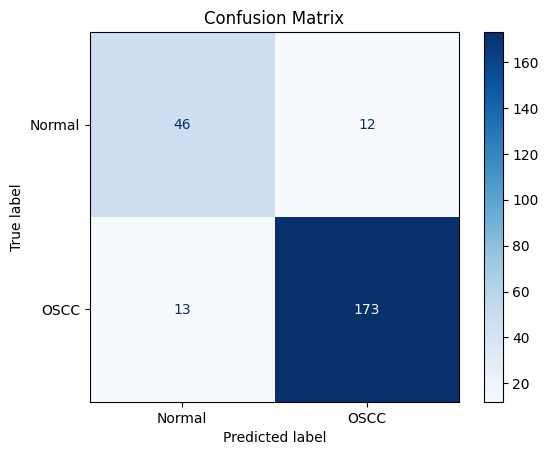

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt

# Ensure 'true' and 'preds' are NumPy arrays
true = np.array(true)
preds = np.array(preds)

# Confusion Matrix
cm = confusion_matrix(true, preds)
tn, fp, fn, tp = cm.ravel()

# Basic Metrics
accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds)
recall = recall_score(true, preds)  # same as TPR
f1 = f1_score(true, preds)
roc_auc = roc_auc_score(true, preds)

# Sensitivity (TPR) and Specificity (TNR)
tpr = tp / (tp + fn)  # Recall
tnr = tn / (tn + fp)

# Print Metrics
print(f"Confusion Matrix:\n{cm}")
print(f"✅ Accuracy       : {accuracy:.4f}")
print(f"✅ Precision      : {precision:.4f}")
print(f"✅ Recall (TPR)   : {recall:.4f}")
print(f"✅ Specificity    : {tnr:.4f}")
print(f"✅ F1-Score       : {f1:.4f}")
print(f"✅ ROC-AUC Score  : {roc_auc:.4f}")

# Detailed classification report (optional)
print("\n📋 Classification Report:")
print(classification_report(true, preds, target_names=["Normal", "OSCC"]))

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "OSCC"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


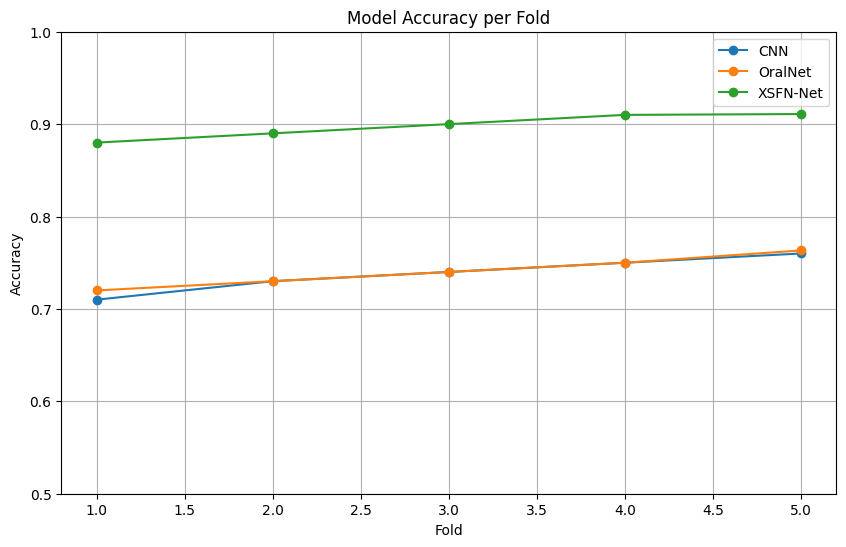

/tmp/ipython-input-5-4044545822.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_acc.keys()), y=list(avg_acc.values()), palette="viridis")


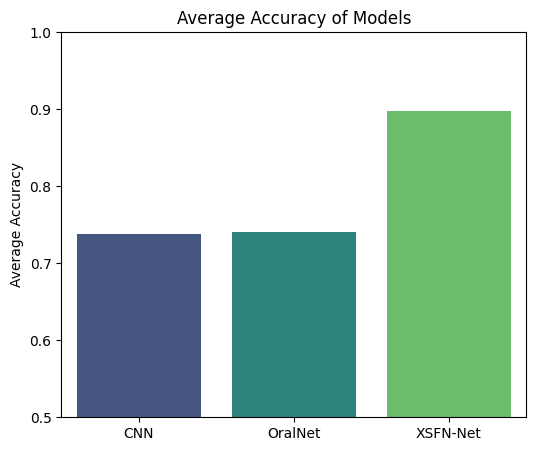

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy results for each fold
results = {
    "CNN": [0.71, 0.73, 0.74, 0.75, 0.7600],
    "OralNet": [0.72, 0.73, 0.74, 0.75, 0.7633],
    "XSFN-Net": [0.88, 0.89, 0.90, 0.91, 0.9109],

}

folds = [1, 2, 3, 4, 5]

# --- Line plot: Accuracy per fold
plt.figure(figsize=(10, 6))
for model, acc in results.items():
    plt.plot(folds, acc, marker='o', label=model)

plt.title("Model Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.50, 1.00)
plt.grid(True)
plt.legend()
plt.show()

# --- Bar plot: Average accuracy
avg_acc = {model: sum(acc) / len(acc) for model, acc in results.items()}
plt.figure(figsize=(6, 5))
sns.barplot(x=list(avg_acc.keys()), y=list(avg_acc.values()), palette="viridis")
plt.title("Average Accuracy of Models")
plt.ylabel("Average Accuracy")
plt.ylim(0.50, 1.00)
plt.show()